In [134]:
import pyspi

In [135]:
import pandas as pd
import os
import matplotlib.pyplot as plt
from scripts.utils import * 

## Exploring an example
Example subject pairs: (103, 203), (108, 208)  
Example word: birthday  
Example conditions: ground (103), board (108)

We load data and interpolate because the movement is 30fps and the pitch is 500fps.


TODO: code is messy and will need more geenralisation when we do this with all data.

In [259]:
def who_pair(filename):
    if 'clue' in filename:
        return 'clueGiver'
    else:
        return 'guesser'

def interpolate(bdf, pdf, bfps = 30, pfps = 500):
    # only for the clueGiver as that is the first column
    lenb = len(bdf)
    lenp = len(pdf)
    times = np.arange(0, lenp + 1) / pfps
    bint = np.interp(times, np.arange(0, lenb) / bfps,
                     bdf[bdf.columns[1]])
    return pd.DataFrame({ 't': times, 'eyebrows_interp': bint })

def load_pair(pair_str):
    brow_files  = [ f'../example/eyebrows/motion/{name}'
                    for name in sorted(os.listdir('../example/eyebrows/motion'))
                    if '.csv' in name and pair_str in name ]
    pitch_files = [ f'../example/pitch/cleaned/{name}' 
                    for name in sorted(os.listdir('../example/pitch/cleaned')) 
                    if '.csv' in name and pair_str in name ]
    
    print(f"Loading files for pair {pair_str}: {brow_files, pitch_files}")
    
    bdfs = [ pd.read_csv(f, skiprows = 1, names = ['t', 'eyebrows_' + who_pair(f) ] ) for f in brow_files ]
    pdfs = [ pd.read_csv(f, skiprows = 1, names = ['t', 'pitch_'    + who_pair(f) ] ) for f in pitch_files ]

    # only for the clueGiver
    ibdf = interpolate(bdfs[0], pdfs[0])
    ibdf = ibdf.drop(ibdf.tail(1).index)

    merged = pd.DataFrame( { 't': a['t'], 
                             'eyebrows_interp': a['eyebrows_interp'],
                             'pitch': b['pitch_clueGiver'] })
    
    # if we want both clueGiver and guesser
    #bdf = pd.merge(bdfs[0], bdfs[1])
    #if len(pdfs) > 1:
    #    pdf = pd.merge(pdfs[0], pdfs[1])
    #else:
    #    pdf = pdfs[0]
        
    return merged.set_index('t')

In [260]:
merged = load_pair('103_203')

Loading files for pair 103_203: (['../example/eyebrows/motion/103_203_birthday_ground_clueGiver.csv', '../example/eyebrows/motion/103_203_birthday_ground_guesser.csv'], ['../example/pitch/cleaned/103_203_birthday_ground_clueGiver.csv'])


In [253]:
#
for pair in [ '103_203', '108_208' ]:
    merged = load_pair(pair)
    name = '103_203_birthday_ground_guesser.csv'
    merged.to_csv(f"../example/merged/{name}"

## Example of interpolation

In [213]:
bdf = pd.read_csv('../example/eyebrows/motion/103_203_birthday_ground_clueGiver.csv', skiprows = 1,
                  names = ['t', 'eyebrows_clueGiver'])
pdf = pd.read_csv('../example/pitch/cleaned/103_203_birthday_ground_clueGiver.csv',   skiprows = 1,
                  names = ['t', 'pitch_clueGiver']) 
ibdf = interpolate(bdf, pdf)

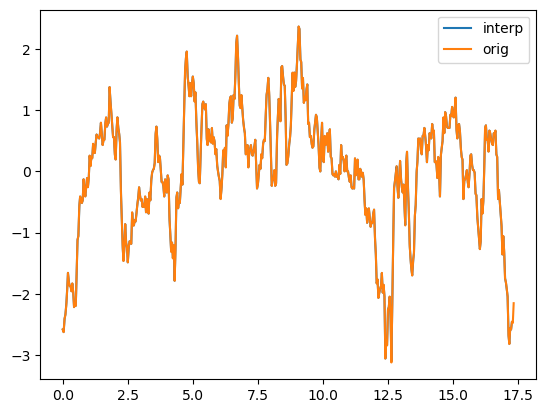

In [214]:
plt.plot(ibdf['t'], ibdf['eyebrows_interp'], label='interp')
plt.plot(bdf['t'] / 30,  bdf['eyebrows_clueGiver'], label='orig')
plt.legend()
plt.show()

<Axes: >

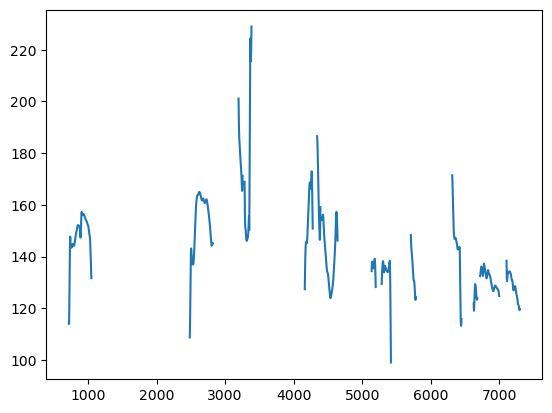

In [215]:
pdf['pitch_clueGiver'].plot()